# Chronic Kidney Disease Dataset - Exploratory Data Analysis

This notebook performs dataset understanding and preprocessing for the Chronic Kidney Disease (CKD) dataset.

Objectives:
- Understand dataset structure
- Identify target variable
- Detect missing values
- Separate numerical and categorical features
- Perform basic exploratory data analysis

## Importing Required Libraries

We first import the necessary Python libraries used for data analysis and visualization.
- **pandas** → for data manipulation
- **numpy** → for numerical operations
- **matplotlib & seaborn** → for visualization
- **scipy** → to load the ARFF dataset format

In [1]:
pip install liac-arff

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11781 sha256=56ff401cf2521898497ec7250c08272b729ec2d1be7b3ea3acc672848b73dab6
  Stored in directory: c:\users\kavya sharma\appdata\local\pip\cache\wheels\a9\ac\cf\c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install seaborn

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff

In [4]:
sns.set_style("whitegrid")

## Loading the Dataset

The Chronic Kidney Disease dataset is loaded using pandas.
This dataset contains medical attributes used to predict whether a patient has CKD.

In [3]:
df = pd.read_csv("../data/raw/Chronic_Kidney_Disease/kidney_disease.csv")

## Dataset Overview

In this section, we perform an initial exploration of the dataset to understand its structure.

The following steps are performed:

- Preview the dataset
- Check dataset dimensions
- List all feature names
- View dataset information and data types
- Identify missing values

These steps help us understand the dataset before performing deeper analysis.

In [5]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [6]:
# Preview first few rows
print("First 10 Rows of Dataset:")
display(df.head(10))

print("\n-----------------------------------")

# Dataset shape
print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\n-----------------------------------")

# Column names
print("Feature Names:")
print(df.columns)

print("\n-----------------------------------")

# Dataset info
print("Dataset Information:")
df.info()

print("\n-----------------------------------")

# Missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

First 10 Rows of Dataset:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd
5,5,60.0,90.0,1.015,3.0,0.0,NaN,NaN,notpresent,notpresent,...,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,6,68.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,...,36,NaN,NaN,no,no,no,good,no,no,ckd
7,7,24.0,NaN,1.015,2.0,4.0,normal,abnormal,notpresent,notpresent,...,44,6900,5,no,yes,no,good,yes,no,ckd
8,8,52.0,100.0,1.015,3.0,0.0,normal,abnormal,present,notpresent,...,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,9,53.0,90.0,1.020,2.0,0.0,abnormal,abnormal,present,notpresent,...,29,12100,3.7,yes,yes,no,poor,no,yes,ckd



-----------------------------------
Dataset Shape (Rows, Columns):
(400, 26)

-----------------------------------
Feature Names:
Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='str')

-----------------------------------
Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    

## Missing Value Analysis

The dataset contains several missing values represented as NaN.

Some medical attributes such as red blood cells (rbc), pus cell (pc), white blood cell count (wc), and red blood cell count (rc) contain missing observations.

These missing values will need to be handled during the preprocessing stage using appropriate techniques such as imputation or removal depending on the importance of the feature.

## Target Variable Analysis

The `classification` column is the target variable in this dataset.  
It indicates whether a patient has **Chronic Kidney Disease (CKD)** or **Not CKD**.

Before training machine learning models, we analyze the distribution of the target variable to understand how many samples belong to each class.

In [7]:
# count how many records belong to each class (CKD vs Not CKD)
df['classification'].value_counts()

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64

The dataset contains more CKD cases than non-CKD cases, indicating a slight class imbalance.

### Visualizing Class Distribution

A count plot is used to visualize the number of CKD and non-CKD cases.

e:\Minor project\AI-Based-Medical-Test-Triage\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


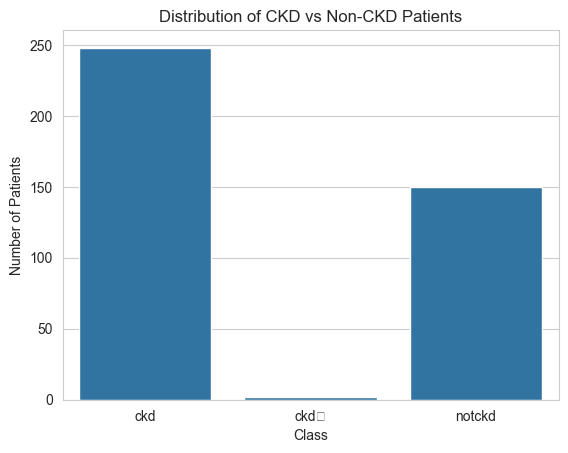

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='classification', data=df)

plt.title("Distribution of CKD vs Non-CKD Patients")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

plt.show()

## Feature Categorization

The dataset contains both numerical and categorical features.  
Separating them helps in selecting appropriate preprocessing techniques later.

In [9]:
df.drop("id", axis=1, inplace=True)

In [11]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:")
for col in categorical_features:
    print("-", col)

print("\nNumerical Features:")
for col in numerical_features:
    print("-", col)

Categorical Features:
- rbc
- pc
- pcc
- ba
- pcv
- wc
- rc
- htn
- dm
- cad
- appet
- pe
- ane
- classification

Numerical Features:
- age
- bp
- sg
- al
- su
- bgr
- bu
- sc
- sod
- pot
- hemo


C:\Users\Kavya Sharma\AppData\Local\Temp\ipykernel_23644\3183658652.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


### Checking Unique Values

We inspect the unique values in categorical columns to see if numerical values have been added as strings.

In [12]:
for col in categorical_features:
    print(col, df[col].unique())

rbc <StringArray>
[nan, 'normal', 'abnormal']
Length: 3, dtype: str
pc <StringArray>
['normal', 'abnormal', nan]
Length: 3, dtype: str
pcc <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
ba <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
pcv <StringArray>
[  '44',   '38',   '31',   '32',   '35',   '39',   '36',   '33',   '29',
   '28',    nan,   '16',   '24',   '37',   '30',   '34',   '40',   '45',
   '27',   '48',  '\t?',   '52',   '14',   '22',   '18',   '42',   '17',
   '46',   '23',   '19',   '25',   '41',   '26',   '15',   '21',   '43',
   '20', '\t43',   '47',    '9',   '49',   '50',   '53',   '51',   '54']
Length: 45, dtype: str
wc <StringArray>
[  '7800',   '6000',   '7500',   '6700',   '7300',      nan,   '6900',
   '9600',  '12100',   '4500',  '12200',  '11000',   '3800',  '11400',
   '5300',   '9200',   '6200',   '8300',   '8400',  '10300',   '9800',
   '9100',   '7900',   '6400',   '8600',  '18900',  '21600',   '4300',
   '8500',  '1130

### Converting String Columns to Numeric

Some numerical features are stored as strings due to inconsistent data formatting.  
We convert them into numeric data types for proper analysis.

In [14]:
cols_to_convert = ['pcv', 'wc', 'rc']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Cleaning Inconsistent Values

Some features contain extra spaces, tab characters.
We clean these values to ensure consistency in the dataset.

In [15]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

In [16]:
for col in categorical_features:
    print(col, df[col].unique())

for col in numerical_features:
    print(col, df[col].unique())

rbc <StringArray>
[nan, 'normal', 'abnormal']
Length: 3, dtype: str
pc <StringArray>
['normal', 'abnormal', nan]
Length: 3, dtype: str
pcc <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
ba <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str
pcv [44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48. 52. 14. 22. 18. 42. 17. 46. 23. 19. 25. 41. 26. 15. 21. 43. 20.
 47.  9. 49. 50. 53. 51. 54.]
wc [ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.
  9800.  9100.  7900.  6400.  8600. 18900. 21600.  4300.  8500. 11300.
  7200.  7700. 14600.  6300.  7100. 11800.  9400.  5500.  5800. 13200.
 12500.  5600.  7000. 11900. 10400. 10700. 12700.  6800.  6500. 13600.
 10200.  9000. 14900.  8200. 15200.  5000. 16300. 12400. 10500.  4200.
  4700. 10900.  8100.  9500.  2200. 12800. 11200. 19100. 12300. 16700.
  2600. 26400.  8800.  7400.  4900.  8000. 1

### Reclassifying numerical columns stored as strings

In [17]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical Features:")
for col in categorical_features:
    print("-", col)

print("\nNumerical Features:")
for col in numerical_features:
    print("-", col)

Categorical Features:
- rbc
- pc
- pcc
- ba
- htn
- dm
- cad
- appet
- pe
- ane
- classification

Numerical Features:
- age
- bp
- sg
- al
- su
- bgr
- bu
- sc
- sod
- pot
- hemo
- pcv
- wc
- rc


C:\Users\Kavya Sharma\AppData\Local\Temp\ipykernel_23644\3183658652.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=['object']).columns.tolist()


### Observation

The dataset contains both numerical and categorical features.

Numerical features include physiological measurements such as blood pressure, blood glucose, and hemoglobin levels.  

Categorical features represent medical conditions such as hypertension, diabetes, anemia, and the target variable classification.

During preprocessing, it was observed that some numerical features were stored as strings and contained inconsistent values such as tab characters. These were cleaned by removing whitespace and converting the columns to appropriate numeric data types.

After cleaning, these features were correctly identified as numerical, and missing values were represented as NaN for further processing.

Proper handling of these features is necessary before training machine learning models.

## Feature Description

| Feature | Description |
|-------|-------------|
| age | Age of patient |
| bp | Blood pressure |
| sg | Specific gravity |
| al | Albumin level |
| su | Sugar level |
| rbc | Red blood cells condition |
| pc | Pus cell |
| pcc | Pus cell clumps |
| ba | Bacteria presence |
| bgr | Blood glucose random |
| bu | Blood urea |
| sc | Serum creatinine |
| sod | Sodium |
| pot | Potassium |
| hemo | Hemoglobin |
| pcv | Packed cell volume |
| wc | White blood cell count |
| rc | Red blood cell count |
| htn | Hypertension |
| dm | Diabetes mellitus |
| cad | Coronary artery disease |
| appet | Appetite |
| pe | Pedal edema |
| ane | Anemia |
| classification | Target variable (CKD / Not CKD) |

## Distribution of Numerical Features

We visualize the distribution of key numerical features to understand their spread and detect possible outliers.

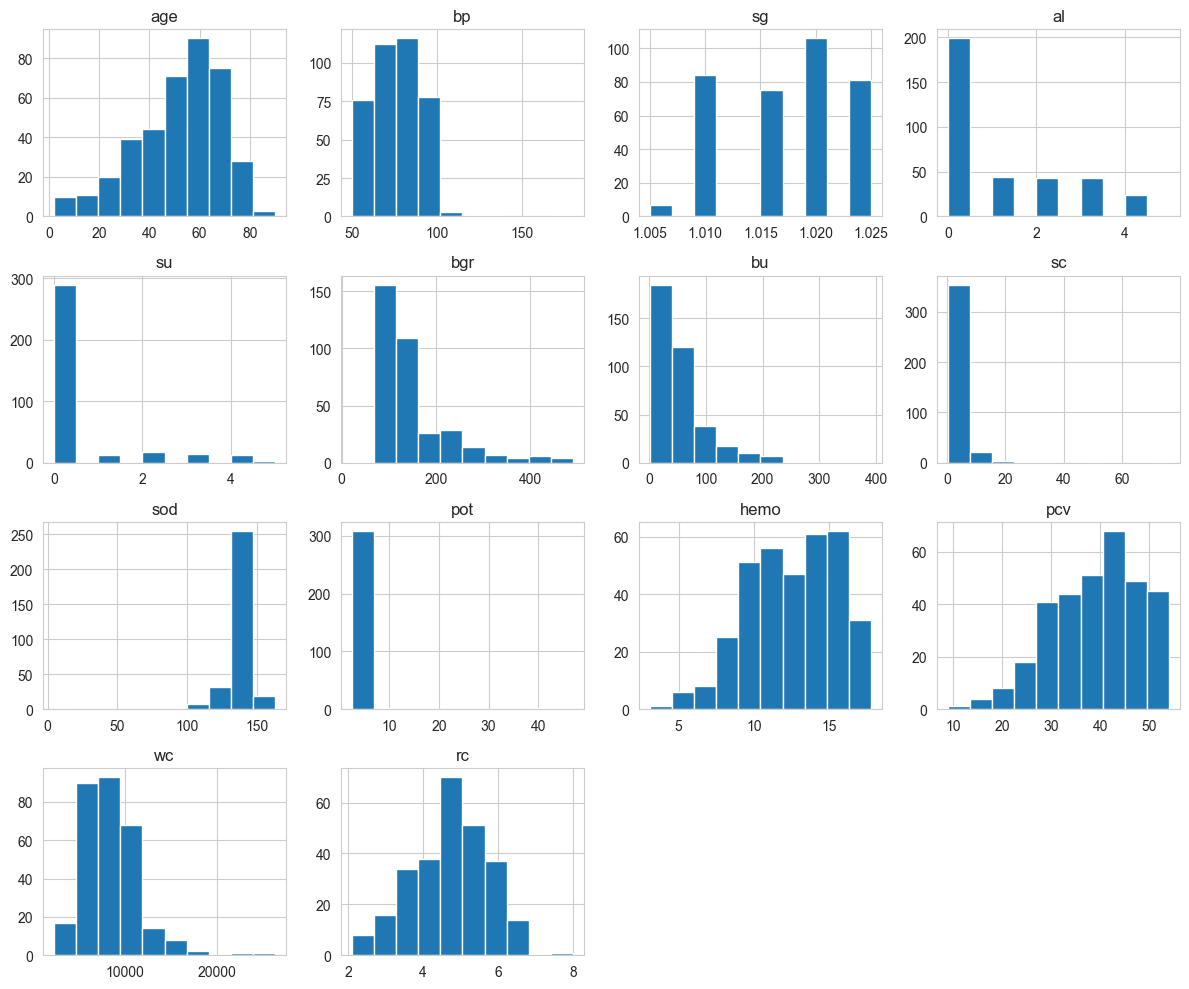

In [18]:
df[numerical_features].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## Observations from Numerical Feature Distributions

• The **age** feature shows a roughly normal distribution with most patients between 40–70 years.

• **Blood pressure (bp)** values are mostly concentrated between 60 and 100.

• **Specific gravity (sg)** takes a few discrete values such as 1.005, 1.010, 1.015, 1.020, and 1.025, indicating that it is measured at fixed medical intervals.

• **Albumin (al)** and **Sugar (su)** values are highly concentrated at 0, suggesting that most patients have normal levels, leading to class imbalance in these features.

Features such as sg, al, and su, although numeric, are discrete/ordinal in nature and represent categorical intensity levels rather than continuous measurements.

• **Blood glucose random (bgr)**, **blood urea (bu)**, and **serum creatinine (sc)** show right-skewed distributions, meaning a few patients have very high values.
Extremely high values in features like serum creatinine (sc) and blood urea (bu) may indicate impaired kidney function, making them important predictors for the target variable.

• **Hemoglobin (hemo)** shows a fairly normal distribution between approximately 8 and 17.

• **Hemoglobin (hemo)**,  **packed cell volume (pcv)**, and  **red blood cell count (rc)** show approximately normal distributions, making them suitable for standard scaling.

• **Sodium (sod)** values are concentrated around the normal physiological range (135–150).

• **Potassium (pot)** shows a strong concentration around lower values with a few extreme outliers.

• After converting categorical features to numeric, it is important to ensure that no invalid or missing values were introduced during type casting.

• The dataset contains a mix of continuous, discrete, and skewed features, indicating that a combination of log transformation, normalization, and standardization may be required during preprocessing for optimal model performance.

## Correlation Analysis

Correlation helps identify relationships between numerical features in the dataset.

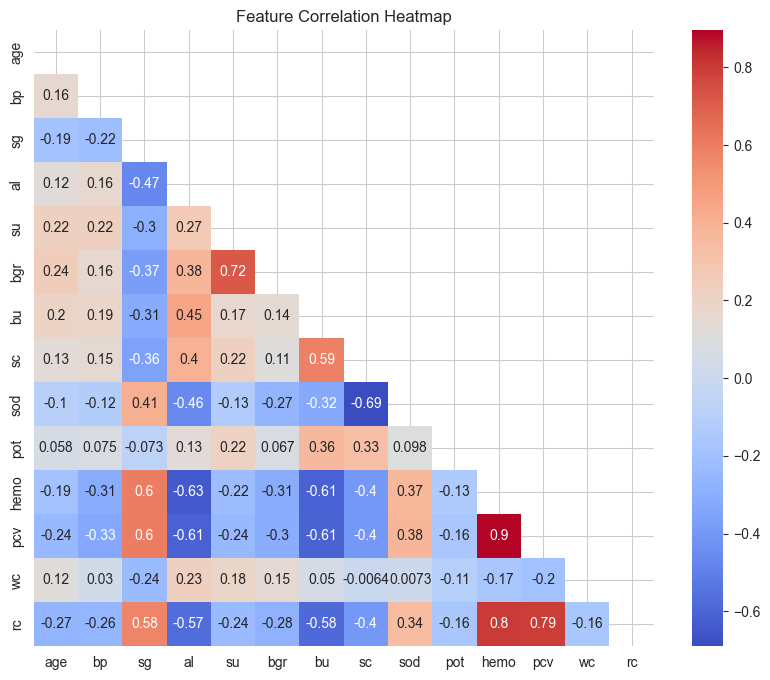

In [19]:
mask = np.triu(np.ones_like(df[numerical_features].corr(), dtype=bool))

plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_features].corr(), mask=mask, cmap="coolwarm", annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

## Correlation Analysis Observations

The heatmap illustrates the relationships between numerical medical features and highlights key dependencies among them.

• **Blood Glucose Random (bgr)** and **Sugar (su)** show a strong positive correlation (≈ 0.72), indicating that higher sugar levels are associated with higher blood glucose levels.

• **Blood Urea (bu)** and **Serum Creatinine (sc)** have a strong positive correlation (≈ 0.59), as both are critical indicators of kidney function and tend to increase together in cases of kidney dysfunction.

• **Hemoglobin (hemo)** shows strong negative correlations with:
   • **Albumin (al)** (≈ -0.63)
   • **Blood Urea (bu)** (≈ -0.61)
   • **Serum Creatinine (sc)** (≈ -0.40)
This suggests that worsening kidney condition is associated with lower hemoglobin levels (anemia).

• **Sodium (sod)** and **Serum Creatinine (sc)** exhibit a strong negative correlation **(≈ -0.69)**, indicating an inverse relationship where kidney dysfunction may impact electrolyte balance.

• **Specific Gravity (sg)** shows:
   • Positive correlation with **Hemoglobin (hemo) (≈ 0.60)**
   • Negative correlation with **Albumin (al) (≈ -0.47)**
This suggests better kidney concentration ability is associated with healthier conditions.

• **Packed Cell Volume (pcv)** and **Hemoglobin (hemo)** have a very strong positive correlation **(≈ 0.90)**, indicating redundancy, as both measure related aspects of blood composition.

• **Red Blood Cell Count (rc)** also shows strong positive correlation with **Hemoglobin (hemo)** (≈ 0.80) and **PCV** (≈ 0.79), further confirming multicollinearity among blood-related features.

• Most other feature pairs show weak to moderate correlations, indicating that many variables contribute independently to the dataset.

## Handling Missing Values (Numerical Features)

Missing values in numerical features are replaced using the mean of each column.
This helps preserve the dataset size and maintain statistical consistency.

In [20]:
# Fill missing values in numerical columns with mean
for col in numerical_features:
    df[col] = df[col].fillna(df[col].mean())

## Handling Missing Values (Categorical Features)
Mean cannot be used for categorical data, so we use mode.

In [21]:
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
for col in categorical_features:
    print(col, df[col].unique())

for col in numerical_features:
    print(col, df[col].unique())

rbc <StringArray>
['normal', 'abnormal']
Length: 2, dtype: str
pc <StringArray>
['normal', 'abnormal']
Length: 2, dtype: str
pcc <StringArray>
['notpresent', 'present']
Length: 2, dtype: str
ba <StringArray>
['notpresent', 'present']
Length: 2, dtype: str
htn <StringArray>
['yes', 'no']
Length: 2, dtype: str
dm <StringArray>
['yes', 'no']
Length: 2, dtype: str
cad <StringArray>
['no', 'yes']
Length: 2, dtype: str
appet <StringArray>
['good', 'poor']
Length: 2, dtype: str
pe <StringArray>
['no', 'yes']
Length: 2, dtype: str
ane <StringArray>
['no', 'yes']
Length: 2, dtype: str
classification <StringArray>
['ckd', 'notckd']
Length: 2, dtype: str
age [48.          7.         62.         51.         60.         68.
 24.         52.         53.         50.         63.         40.
 47.         61.         21.         42.         75.         69.
 51.48337596 73.         70.         65.         76.         72.
 82.         46.         45.         35.         54.         11.
 59.         67.   

## Encoding Categorical Features

Machine learning models cannot work with textual data such as "yes", "no", "normal", or "abnormal".  
Therefore, categorical features are converted into numerical values using encoding techniques.

In this dataset, most categorical features are binary in nature, so we use **label encoding (manual mapping)** to convert them into 0s and 1s.

### Checking Unique Values

We inspect the unique values in categorical columns to understand how to encode them correctly.

In [23]:
for col in categorical_features:
    print(col, df[col].unique())

rbc <StringArray>
['normal', 'abnormal']
Length: 2, dtype: str
pc <StringArray>
['normal', 'abnormal']
Length: 2, dtype: str
pcc <StringArray>
['notpresent', 'present']
Length: 2, dtype: str
ba <StringArray>
['notpresent', 'present']
Length: 2, dtype: str
htn <StringArray>
['yes', 'no']
Length: 2, dtype: str
dm <StringArray>
['yes', 'no']
Length: 2, dtype: str
cad <StringArray>
['no', 'yes']
Length: 2, dtype: str
appet <StringArray>
['good', 'poor']
Length: 2, dtype: str
pe <StringArray>
['no', 'yes']
Length: 2, dtype: str
ane <StringArray>
['no', 'yes']
Length: 2, dtype: str
classification <StringArray>
['ckd', 'notckd']
Length: 2, dtype: str


## Observation (after cleaning & handling missing values)

• All categorical features have been standardized and cleaned, removing inconsistencies such as extra spaces, case differences, and noisy values.

• Most categorical features are now binary in nature, containing only two distinct values:

  Example:

  rbc, pc → normal / abnormal

  pcc, ba → present / notpresent

  htn, dm, cad → yes / no

  appet → good / poor

• The target variable classification is also binary:

  ckd (Chronic Kidney Disease)

  notckd

• This confirms that the problem is a *Binary Classification Problem*, suitable for models like:

  Logistic Regression

  Random Forest
  
  Decision Tree

Since all categorical variables are binary, they can be efficiently converted into numerical format using label encoding (0/1 mapping) without increasing dimensionality.

In [24]:
df.isnull().sum() #no null or nan values remain after cleaning and handling missing values

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

## Preprocessing / Feature Engineering

### Categorical Encoding

Since all categorical features contain only **two unique values**, **Label Encoding** is applied instead of One-Hot Encoding.

Each category is mapped to numerical values:

- yes / present / abnormal → **1**  
- no / notpresent / normal → **0**

**Example mappings:**

| Feature         | Original Values | Encoded Values |
|-----------------|----------------|----------------|
| htn             | yes / no       | 1 / 0          |
| rbc             | normal / abnormal | 0 / 1       |
| classification  | ckd / notckd   | 1 / 0          |

**Benefits of this approach:**

- Keeps the dataset compact  
- Avoids unnecessary feature expansion  
- Improves model efficiency

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


# Step 3: List of categorical features
categorical_features_encoded = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']

# Step 4: Initialize LabelEncoder
le = LabelEncoder()

# Step 5: Apply encoding to each categorical feature
for col in categorical_features_encoded:
    df[col] = le.fit_transform(df[col])

# Step 6: Check the result
df[categorical_features_encoded].head()

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,classification
0,1,1,0,0,1,1,0,0,0,0,0
1,1,1,0,0,0,0,0,0,0,0,0
2,1,1,0,0,0,1,0,1,0,1,0
3,1,0,1,0,1,0,0,1,1,1,0
4,1,1,0,0,0,0,0,0,0,0,0


## Processed Dataset Saved

The cleaned and preprocessed dataset has been saved for further analysis and model training.

This dataset is now ready to be used for machine learning tasks such as model building, evaluation, and prediction.

In [27]:
import os

os.makedirs("../data/processed/Chronic_Kidney_Disease", exist_ok=True)

df.to_csv("../data/processed/Chronic_Kidney_Disease/processed_kidney_disease.csv", index=False)